<a href="https://colab.research.google.com/github/SSAcer-19/MNIST-Project/blob/main/mnist_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import regularizers


In [ ]:
import cv2
import imutils
!pip install easyocr
import easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 27.5 MB/s eta 0:00:00


In [ ]:
cap= cv2.VideoCapture(0+cv2.CAP_DSHOW)
while True:
  _, frame =cap.read()
  frame =cv2.rotate(frame,cv2.ROTATE_180)
  frame_copy=frame.copy()
  cv2.imshow("input",frame_copy)
  if cv2.waitKey(1) & 0xFF==27:
    break
  cv2.destroyAllWindows

AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
(x_train,y_train), (x_test,y_test)= keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
len(x_train)

60000

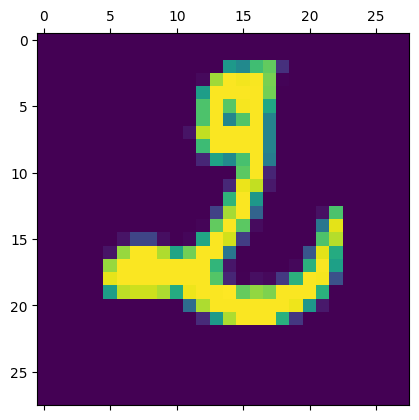

In [ ]:
plt.matshow(x_train[190])

In [ ]:
x_train=x_train/255
x_test=x_test/255

In [ ]:
print(x_test.shape)

(10000,)


In [ ]:
x_train_flatten=x_train.reshape(len(x_train),28*28)
x_test_flatten=x_test.reshape(-1,28*28)

In [ ]:
model1=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100,activation='relu',kernel_regularizer=regularizers.l2(0.01)),
    keras.layers.Dense(10,activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model1.fit(x_train,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8564 - loss: 0.9311
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9212 - loss: 0.4186
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9358 - loss: 0.3626
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9418 - loss: 0.3357
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9456 - loss: 0.3189


In [ ]:
y_predicted=model1.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]

In [ ]:
cm= tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)


Text(95.72222222222221, 0.5, 'Truth')

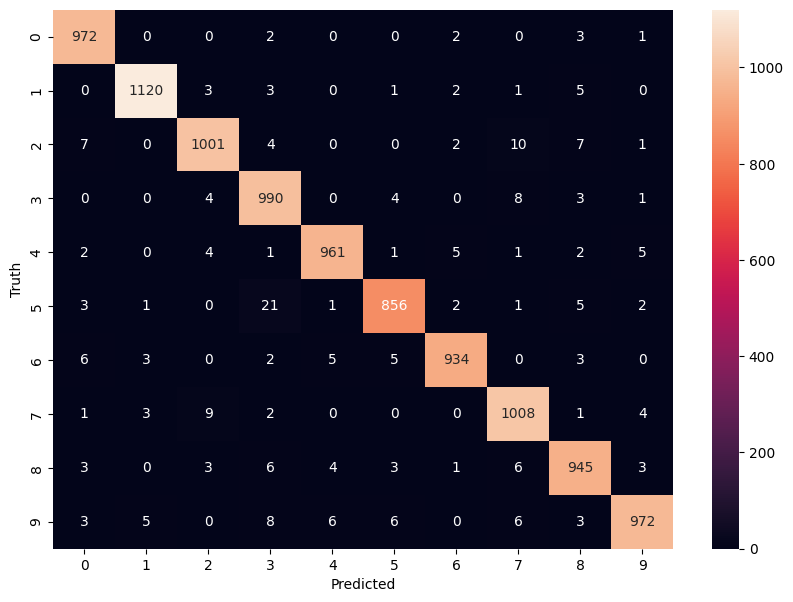

In [ ]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')